In [ ]:
# print file tree
import h5py
import pandas as pd

with h5py.File("data/2x4-hits-full.hdf5", "r") as f:
    def print_tree(name, obj):
        print(name)


    f.visititems(print_tree)


hits
[(5, 935, 363,  95, 539844) (5, 919, 333,  38, 540300)
 (5, 920, 294, 129, 540785) (5, 921, 294, 112, 540787)
 (5, 951, 292,  79, 541096)]


In [109]:
# read h5 file
import h5py
import pandas as pd
import numpy as np

with h5py.File('data/2x4-hits-full.hdf5', 'r') as f:
    hits = f['hits'][:]  # Load all hits
    print(len(hits))
    ToA = hits['ToA']     # Access specific field
    x = hits['x']
    y = hits['y']
    ToT = hits['ToT']
print(hits[0:100])


296119556
[(5, 935, 363,  95, 539844) (5, 919, 333,  38, 540300)
 (5, 920, 294, 129, 540785) (5, 921, 294, 112, 540787)
 (5, 951, 292,  79, 541096) (5, 940, 315,  85, 541802)
 (5, 941, 315,  82, 541802) (5, 933, 301,  65, 542082)
 (5, 932, 301,  32, 542083) (5, 933, 300,  45, 542083)
 (5, 931, 301,  39, 542086) (5, 933, 367,  52, 543874)
 (5, 928, 304,  32, 545481) (5, 928, 305,  46, 545481)
 (5, 927, 303,  23, 545483) (5, 928, 303,  21, 545483)
 (5, 928, 306,  66, 545484) (5, 927, 305,  24, 545485)
 (5, 927, 306, 101, 545485) (5, 943, 258,  14, 546105)
 (5, 944, 258, 154, 546105) (5, 945, 258,   9, 546106)
 (5, 947, 266,  50, 546861) (5, 947, 267,  59, 546861)
 (5, 948, 266,  60, 546861) (5, 948, 267,  44, 546861)
 (5, 949, 266, 119, 546861) (5, 949, 267,  29, 546865)
 (5, 946, 266,   9, 546866) (5, 930, 384,  48, 547807)
 (5, 931, 383,  56, 547807) (5, 931, 384,  46, 547807)
 (5, 930, 383,  25, 547809) (5, 929, 385,  31, 547811)
 (5, 930, 385,   9, 547813) (5, 929, 386,  52, 547814)


In [99]:
# write h5 file

import numpy as np
import h5py

# initializing a random numpy array
arr = np.random.randn(1000)

# creating a file
with h5py.File('data/2x4-hits-full-reorganised.hdf5', 'w') as f: 
    dset = f.create_dataset("toa", data = ToA)
    dset = f.create_dataset("tot", data = ToT)
    dset = f.create_dataset("x", data = x)
    dset = f.create_dataset("y", data = y)

In [100]:
# read file tree
import h5py
import pandas as pd

with h5py.File("data/2x4-hits-full-reorganised.hdf5", "r") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(print_tree)
    print(len(f['toa']))

toa
tot
x
y
296119556


513
1029


/var/folders/04/jlh9mlqn1k946gj5007pwxv00000gq/T/ipykernel_2725/4128531639.py:23: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(grid), cmap='grey')


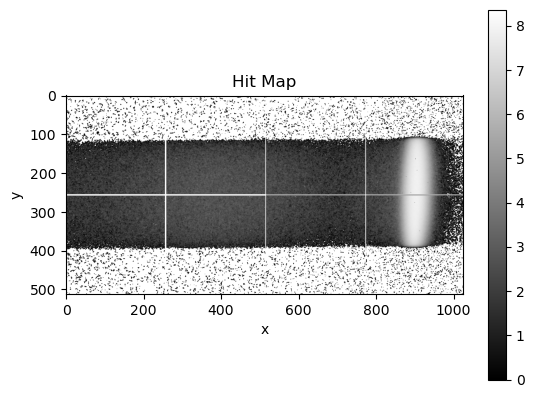

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create empty 512x512 grid
grid = np.zeros((512, 1024), dtype=np.int64)

# Convert to NumPy arrays
y_vals = y
x_vals = x
print(max(y_vals))
print(np.max(x_vals))

# Filter valid pixel coordinates
mask = (x_vals >= 0) & (x_vals < 1024) & (y_vals >= 0) & (y_vals < 512)
x_vals = x_vals[mask]
y_vals = y_vals[mask]

# Accumulate hits
np.add.at(grid, (y_vals, x_vals), 1)

# Plot
plt.figure()
plt.imshow(np.log(grid+1), cmap='grey')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Hit Map")
plt.colorbar()
plt.show()

In [2]:
# look at clusters
import h5py
import pandas as pd

with h5py.File("output_clusters_kuttruff/output_multithread.hdf5", "r") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(print_tree)

dir
dir/max_intens
dir/size
dir/sum_intens
dir/time
dir/x
dir/y


In [4]:
import h5py
import numpy as np

with h5py.File("output_clusters_kuttruff/output_multithread.hdf5", "r") as f:
    max_intens = f["dir/max_intens"][:]
    size = f["dir/size"][:]
    sum_intens = f["dir/sum_intens"][:]
    time = f["dir/time"][:]
    x = f["dir/x"][:]
    y = f["dir/y"][:]

print(len(x),len(y))
print(max_intens[:10])
print(size[:10])
print(x[:20],y[:20])


3379628 3379628
[ 36 114 106  57  95   7 137  72  57  94]
[ 4  3  7  6 12  1 11 12  6  7]
[920 923 807 961 927 924 957 946 942 924 944 941 937 939 931 945 949 950
 959 946] [353 275 210 177 234 231 189 319 321 201 296 311 309 317 179 172 135 328
 311 350]


513
1029


/var/folders/04/jlh9mlqn1k946gj5007pwxv00000gq/T/ipykernel_4235/142673687.py:23: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(grid), cmap='grey')


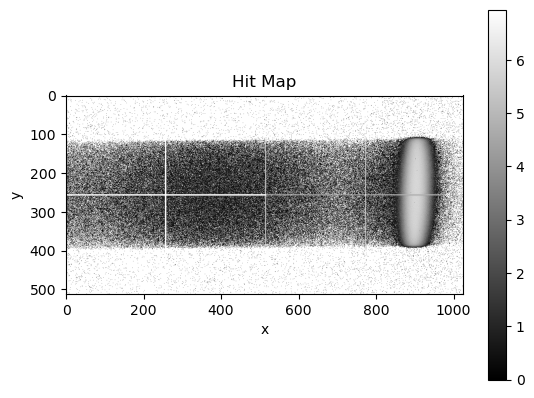

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create empty 512x512 grid
grid = np.zeros((512, 1024), dtype=np.int64)

# Convert to NumPy arrays
y_vals = y
x_vals = x
print(max(y_vals))
print(np.max(x_vals))

# Filter valid pixel coordinates
mask = (x_vals >= 0) & (x_vals < 1024) & (y_vals >= 0) & (y_vals < 512)
x_vals = x_vals[mask]
y_vals = y_vals[mask]

# Accumulate hits
np.add.at(grid, (y_vals, x_vals), 1)

# Plot
plt.figure()
plt.imshow(np.log(grid+1), cmap='grey')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Hit Map")
plt.colorbar()